In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)

# ========== 1. 数据加载 ============

In [4]:

print("="*50)
print("1. 加载 20newsgroups 数据集")
print("="*50)

1. 加载 20newsgroups 数据集


In [5]:
# 加载训练集和测试集
categories = None  # 使用所有类别，也可以指定部分类别如: categories=['alt.atheism', 'comp.graphics', 'sci.space']
train_data = fetch_20newsgroups(subset='train', categories=categories, shuffle=True, random_state=42)
test_data = fetch_20newsgroups(subset='test', categories=categories, shuffle=True, random_state=42)

In [6]:
print(f"训练集样本数: {len(train_data.data)}")
print(f"测试集样本数: {len(test_data.data)}")
print(f"类别数: {len(train_data.target_names)}")
print(f"类别名称: {train_data.target_names[:5]}...")

# 显示一个样本
print(f"\n样本示例:")
print(f"类别: {train_data.target_names[train_data.target[0]]}")
print(f"文本前200字符: {train_data.data[0][:200]}...")

训练集样本数: 11314
测试集样本数: 7532
类别数: 20
类别名称: ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware']...

样本示例:
类别: rec.autos
文本前200字符: From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out...


In [7]:
# ==================== 2. 文本特征提取 ====================
print("\n" + "="*50)
print("2. 文本特征提取（TF-IDF）")
print("="*50)

# 使用 TF-IDF 将文本转换为向量
# 限制词汇量为 5000，避免维度太高
vectorizer = TfidfVectorizer(
    max_features=5000,  # 保留最重要的5000个词
    stop_words='english',  # 去除英文停用词
    ngram_range=(1, 2),  # 使用 unigram 和 bigram
    min_df=2,  # 至少在2个文档中出现
    max_df=0.95  # 最多在95%的文档中出现
)

# 转换文本为特征矩阵
X_train = vectorizer.fit_transform(train_data.data)
X_test = vectorizer.transform(test_data.data)

# 转换为稠密矩阵（全连接网络需要稠密输入）
X_train_dense = X_train.toarray().astype(np.float32)
X_test_dense = X_test.toarray().astype(np.float32)

# 标签编码
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_data.target)
y_test = label_encoder.transform(test_data.target)

print(f"特征维度: {X_train_dense.shape[1]}")
print(f"训练集特征矩阵形状: {X_train_dense.shape}")
print(f"测试集特征矩阵形状: {X_test_dense.shape}")
print(f"类别数: {len(label_encoder.classes_)}")




2. 文本特征提取（TF-IDF）
特征维度: 5000
训练集特征矩阵形状: (11314, 5000)
测试集特征矩阵形状: (7532, 5000)
类别数: 20


In [8]:
# ==================== 3. 数据划分（训练集和验证集） ====================
print("\n" + "="*50)
print("3. 数据划分")
print("="*50)

# 从训练集中划分验证集
X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_train_dense, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"训练集大小: {X_train_part.shape[0]}")
print(f"验证集大小: {X_val.shape[0]}")
print(f"测试集大小: {X_test_dense.shape[0]}")

# 转换为 PyTorch 张量
train_tensor = TensorDataset(
    torch.tensor(X_train_part, dtype=torch.float32),
    torch.tensor(y_train_part, dtype=torch.long)
)
val_tensor = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long)
)
test_tensor = TensorDataset(
    torch.tensor(X_test_dense, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)

# 创建数据加载器
batch_size = 128
train_loader = DataLoader(train_tensor, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_tensor, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_tensor, batch_size=batch_size, shuffle=False)




3. 数据划分
训练集大小: 9051
验证集大小: 2263
测试集大小: 7532


In [9]:
# ==================== 4. 定义全连接网络模型 ====================
print("\n" + "="*50)
print("4. 构建全连接网络模型")
print("="*50)

class TextClassifier(nn.Module):
    """基于全连接网络的文本分类器"""

    def __init__(self, input_dim, hidden_dims, num_classes, dropout_rate=0.5):
        """
        Args:
            input_dim: 输入特征维度（词表大小）
            hidden_dims: 隐藏层维度列表，例如 [512, 256]
            num_classes: 输出类别数
            dropout_rate: Dropout 比率
        """
        super(TextClassifier, self).__init__()

        # 构建网络层
        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = hidden_dim

        # 输出层
        layers.append(nn.Linear(prev_dim, num_classes))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        """前向传播"""
        return self.network(x)

# 模型参数
input_dim = X_train_dense.shape[1]  # 特征维度
hidden_dims = [512, 256]  # 隐藏层维度
num_classes = len(label_encoder.classes_)
dropout_rate = 0.5

model = TextClassifier(input_dim, hidden_dims, num_classes, dropout_rate)

print(f"模型结构:")
print(f"  输入维度: {input_dim}")
print(f"  隐藏层: {hidden_dims}")
print(f"  输出类别数: {num_classes}")
print(f"  模型参数量: {sum(p.numel() for p in model.parameters()):,}")




4. 构建全连接网络模型
模型结构:
  输入维度: 5000
  隐藏层: [512, 256]
  输出类别数: 20
  模型参数量: 2,698,516


In [11]:
# ==================== 5. 训练配置 ====================
print("\n" + "="*50)
print("5. 训练配置")
print("="*50)

# 损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, mode='min', factor=0.5, patience=3, verbose=True
# )
# 修改后（正确）
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)
# 设备配置
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"使用设备: {device}")




5. 训练配置
使用设备: cuda


In [12]:
# ==================== 6. 训练函数 ====================
def train_epoch(model, loader, criterion, optimizer, device):
    """训练一个epoch"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_X, batch_y in loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        # 前向传播
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 统计
        total_loss += loss.item() * batch_X.size(0)
        _, predicted = torch.max(outputs, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

def evaluate(model, loader, criterion, device):
    """评估模型"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_X, batch_y in loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            total_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy, all_preds, all_labels



In [13]:
# ==================== 7. 训练循环 ====================
print("\n" + "="*50)
print("6. 开始训练")
print("="*50)

num_epochs = 50
best_val_acc = 0
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    # 训练
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # 验证
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # 调整学习率
    scheduler.step(val_loss)

    # 保存最佳模型
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')

    # 打印进度
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

print(f"\n训练完成！最佳验证准确率: {best_val_acc:.4f}")




6. 开始训练
Epoch [5/50] Train Loss: 0.0652 | Train Acc: 0.9885 | Val Loss: 0.4570 | Val Acc: 0.8657
Epoch [10/50] Train Loss: 0.0191 | Train Acc: 0.9973 | Val Loss: 0.4915 | Val Acc: 0.8665
Epoch [15/50] Train Loss: 0.0098 | Train Acc: 0.9986 | Val Loss: 0.5018 | Val Acc: 0.8705
Epoch [20/50] Train Loss: 0.0065 | Train Acc: 0.9991 | Val Loss: 0.5075 | Val Acc: 0.8705
Epoch [25/50] Train Loss: 0.0072 | Train Acc: 0.9992 | Val Loss: 0.5034 | Val Acc: 0.8719
Epoch [30/50] Train Loss: 0.0063 | Train Acc: 0.9992 | Val Loss: 0.5106 | Val Acc: 0.8723
Epoch [35/50] Train Loss: 0.0060 | Train Acc: 0.9992 | Val Loss: 0.5082 | Val Acc: 0.8719
Epoch [40/50] Train Loss: 0.0052 | Train Acc: 0.9994 | Val Loss: 0.5118 | Val Acc: 0.8701
Epoch [45/50] Train Loss: 0.0048 | Train Acc: 0.9997 | Val Loss: 0.5096 | Val Acc: 0.8727
Epoch [50/50] Train Loss: 0.0054 | Train Acc: 0.9991 | Val Loss: 0.5103 | Val Acc: 0.8701

训练完成！最佳验证准确率: 0.8816



7. 可视化训练过程


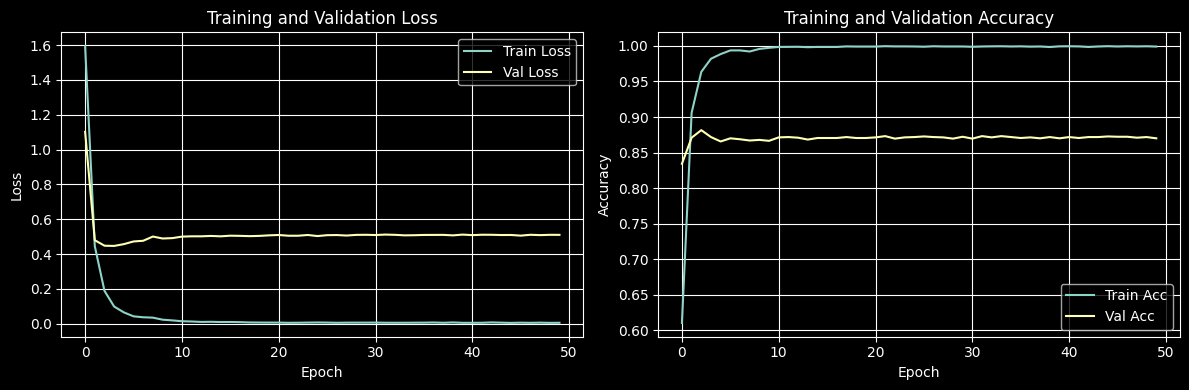

In [15]:
# ==================== 8. 可视化训练过程 ====================
print("\n" + "="*50)
print("7. 可视化训练过程")
print("="*50)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 损失曲线
axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# 准确率曲线
axes[1].plot(train_accs, label='Train Acc')
axes[1].plot(val_accs, label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=100)
plt.show()



In [17]:
# ==================== 9. 测试集评估 ====================
print("\n" + "="*50)
print("8. 测试集评估")
print("="*50)

# 加载最佳模型
model.load_state_dict(torch.load('best_model.pth'))

# 在测试集上评估
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, device)
print(f"\n测试集结果:")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_acc:.4f}")

# 详细分类报告
# print("\n分类报告:")
# print(classification_report(test_labels, test_preds,
#                             target_names=label_encoder.classes_,
#                             digits=4))
# 在分类报告中使用 train_data.target_names
print("\n分类报告:")
print(classification_report(test_labels, test_preds,
                            target_names=train_data.target_names,  # 使用原始类别名称
                            digits=4))



8. 测试集评估

测试集结果:
  Loss: 0.7676
  Accuracy: 0.7795

分类报告:
                          precision    recall  f1-score   support

             alt.atheism     0.7299    0.7116    0.7206       319
           comp.graphics     0.6634    0.7044    0.6833       389
 comp.os.ms-windows.misc     0.7556    0.6827    0.7173       394
comp.sys.ibm.pc.hardware     0.6197    0.7066    0.6603       392
   comp.sys.mac.hardware     0.6894    0.7610    0.7235       385
          comp.windows.x     0.8269    0.7013    0.7589       395
            misc.forsale     0.7828    0.8410    0.8109       390
               rec.autos     0.8123    0.7980    0.8051       396
         rec.motorcycles     0.8493    0.8920    0.8701       398
      rec.sport.baseball     0.8744    0.8589    0.8666       397
        rec.sport.hockey     0.9261    0.9424    0.9342       399
               sci.crypt     0.9559    0.8763    0.9144       396
         sci.electronics     0.6514    0.6896    0.6700       393
                


9. 混淆矩阵


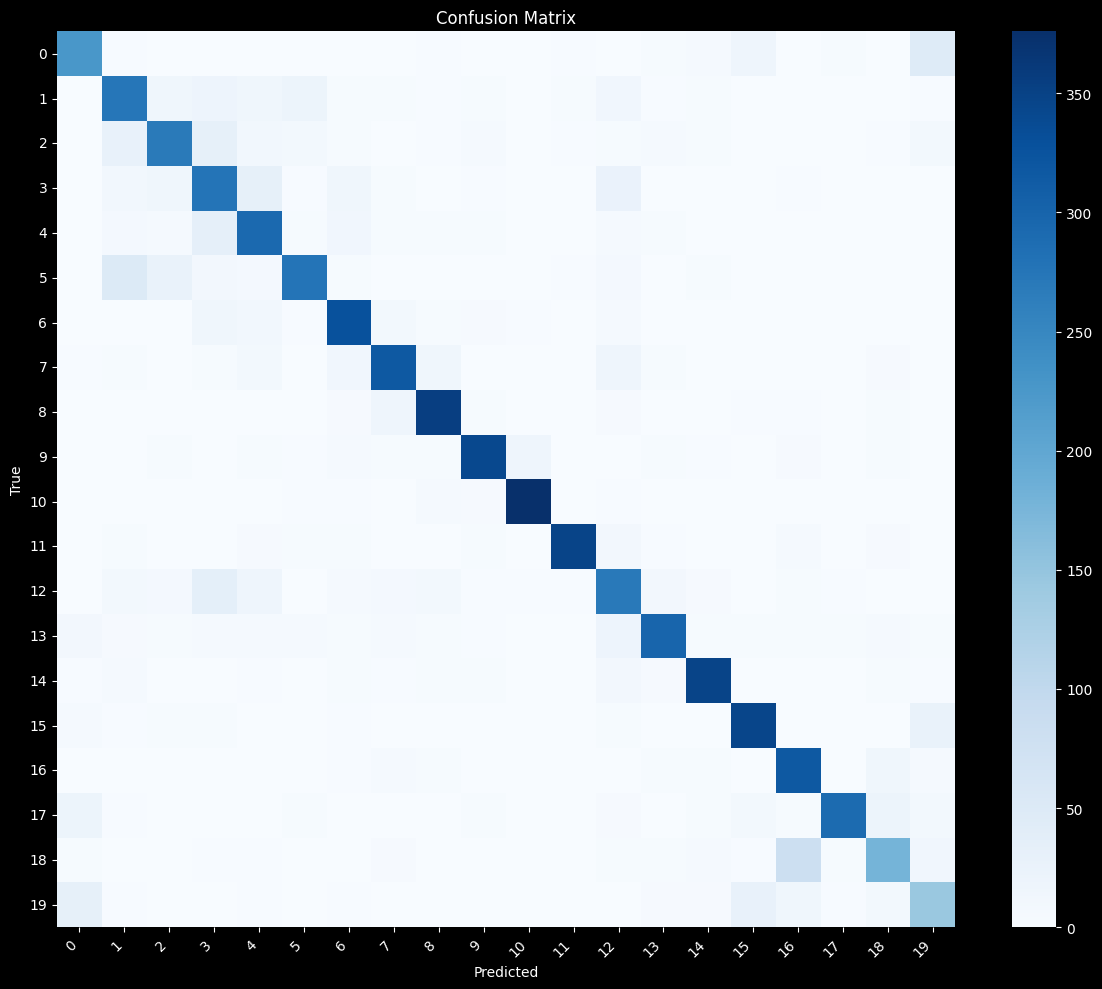


错误分类示例:
样本 1:
  真实类别: 5
  预测类别: 1
  文本前100字: From: Rick Miller <rick@ee.uwm.edu>
Subject: X-Face?
Organization: Just me.
Lines: 17
Distribution: ...

样本 3:
  真实类别: 17
  预测类别: 18
  文本前100字: From: bakken@cs.arizona.edu (Dave Bakken)
Subject: Re: Saudi clergy condemns debut of human rights g...

样本 4:
  真实类别: 19
  预测类别: 0
  文本前100字: From: livesey@solntze.wpd.sgi.com (Jon Livesey)
Subject: Re: After 2000 years, can we say that Chris...

样本 7:
  真实类别: 15
  预测类别: 2
  文本前100字: From: fortmann@superbowl.und.ac.za (Paul Fortmann - PG)
Subject: "The Word Perfect" EXE file needed
...

样本 11:
  真实类别: 5
  预测类别: 1
  文本前100字: From: sirosh@cs.utexas.edu (Joseph Sirosh)
Subject: X Design choice for color handling: question
Org...

样本 13:
  真实类别: 8
  预测类别: 7
  文本前100字: From: ray@unisql.UUCP (Ray Shea)
Subject: Re: Ok, So I was a little hasty...
Organization: UniSQL, I...

样本 14:
  真实类别: 0
  预测类别: 19
  文本前100字: From: acooper@mac.cc.macalstr.edu (Turin Turambar, ME Department of Utter Misery)
Subject: Re:

In [18]:
# ==================== 10. 混淆矩阵 ====================
print("\n" + "="*50)
print("9. 混淆矩阵")
print("="*50)

# 计算混淆矩阵
cm = confusion_matrix(test_labels, test_preds)

# 可视化混淆矩阵
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100)
plt.show()

# 打印一些错误分类的例子
print("\n错误分类示例:")
model.eval()
misclassified = []
with torch.no_grad():
    for i, (X, y) in enumerate(test_tensor):
        X = X.to(device).unsqueeze(0)
        output = model(X)
        pred = torch.argmax(output, dim=1).item()
        true = y.item()
        if pred != true:
            misclassified.append((i, true, pred))
            if len(misclassified) >= 10:
                break

for idx, true, pred in misclassified:
    print(f"样本 {idx}:")
    print(f"  真实类别: {label_encoder.classes_[true]}")
    print(f"  预测类别: {label_encoder.classes_[pred]}")
    print(f"  文本前100字: {test_data.data[idx][:100]}...")
    print()



In [19]:
# ==================== 11. 推理函数 ====================
print("\n" + "="*50)
print("10. 推理函数示例")
print("="*50)

def predict_text(text, model, vectorizer, label_encoder, device):
    """
    对单个文本进行预测

    Args:
        text: 输入文本
        model: 训练好的模型
        vectorizer: TF-IDF 向量化器
        label_encoder: 标签编码器
        device: 设备

    Returns:
        predicted_class: 预测的类别名称
        probabilities: 各类别的概率
    """
    model.eval()

    # 文本特征提取
    text_features = vectorizer.transform([text])
    text_features = text_features.toarray().astype(np.float32)
    text_tensor = torch.tensor(text_features, dtype=torch.float32).to(device)

    # 预测
    with torch.no_grad():
        outputs = model(text_tensor)
        probabilities = torch.softmax(outputs, dim=1).cpu().numpy()[0]
        predicted_idx = np.argmax(probabilities)
        predicted_class = label_encoder.classes_[predicted_idx]

    return predicted_class, probabilities

# 测试推理函数
test_texts = [
    "I love programming in Python and Java. It's so much fun to build software!",
    "The stock market is down today due to economic uncertainty.",
    "The universe is expanding and we are learning more about black holes.",
    "Basketball is my favorite sport. I love watching NBA games.",
]

print("推理示例:")
for text in test_texts:
    pred_class, probs = predict_text(text, model, vectorizer, label_encoder, device)
    top_3_idx = np.argsort(probs)[-3:][::-1]
    print(f"\n文本: {text[:80]}...")
    print(f"预测类别: {pred_class}")
    print("Top 3 预测:")
    for idx in top_3_idx:
        print(f"  {label_encoder.classes_[idx]}: {probs[idx]:.4f}")




10. 推理函数示例
推理示例:

文本: I love programming in Python and Java. It's so much fun to build software!...
预测类别: 12
Top 3 预测:
  12: 0.5209
  5: 0.1606
  1: 0.1305

文本: The stock market is down today due to economic uncertainty....
预测类别: 8
Top 3 预测:
  8: 0.6387
  18: 0.2055
  4: 0.0250

文本: The universe is expanding and we are learning more about black holes....
预测类别: 14
Top 3 预测:
  14: 0.2677
  15: 0.1938
  12: 0.1470

文本: Basketball is my favorite sport. I love watching NBA games....
预测类别: 10
Top 3 预测:
  10: 0.8711
  9: 0.0725
  7: 0.0133


In [20]:
# ==================== 12. 保存模型和向量化器 ====================
print("\n" + "="*50)
print("11. 保存模型和预处理组件")
print("="*50)

# 保存模型
torch.save({
    'model_state_dict': model.state_dict(),
    'input_dim': input_dim,
    'hidden_dims': hidden_dims,
    'num_classes': num_classes,
    'label_encoder': label_encoder,
    'vectorizer': vectorizer,
}, 'text_classifier_full.pth')

print("模型和预处理组件已保存!")
print("\n训练和推理完成!")

# 额外分析：特征重要性（通过第一层权重）
print("\n" + "="*50)
print("12. 特征重要性分析")
print("="*50)

# 获取第一层权重
first_layer_weights = model.network[0].weight.data.cpu().numpy()
# 计算每个特征的平均绝对权重（表示重要性）
feature_importance = np.mean(np.abs(first_layer_weights), axis=0)

# 获取最重要的特征
feature_names = vectorizer.get_feature_names_out()
top_k = 10
top_indices = np.argsort(feature_importance)[-top_k:][::-1]

print(f"\n最重要的 {top_k} 个特征:")
for idx in top_indices:
    print(f"  {feature_names[idx]}: {feature_importance[idx]:.4f}")


11. 保存模型和预处理组件
模型和预处理组件已保存!

训练和推理完成!

12. 特征重要性分析

最重要的 10 个特征:
  dod: 0.0221
  windows: 0.0207
  sale: 0.0207
  bike: 0.0203
  graphics: 0.0194
  mac: 0.0191
  bikes: 0.0186
  car: 0.0184
  space: 0.0182
  baseball: 0.0173
